# MATRIX ICS Testbed — End-to-End Latency Analysis
Loads `e2e_latency_summary.csv` and `e2e_latency_raw.csv` and plots Direct vs Middleware latency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("e2e_latency_summary.csv")
raw = pd.read_csv("e2e_latency_raw.csv")

devices = summary["device"].tolist()
raw.head()

,device,path,sample,latency_ms
0,Siemens S7-1200,Direct,1,61.5100
1,Siemens S7-1200,Direct,2,60.1323
2,Siemens S7-1200,Direct,3,60.5634
3,Siemens S7-1200,Direct,4,53.4446
4,Siemens S7-1200,Direct,5,64.9459


## 1. Box-and-Whisker Plots — Direct vs Middleware (per device)

C:\Users\chabz\AppData\Local\Temp\ipykernel_6288\1514642811.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([direct_vals, middleware_vals], labels=["Direct", "Middleware"], showfliers=True)
C:\Users\chabz\AppData\Local\Temp\ipykernel_6288\1514642811.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([direct_vals, middleware_vals], labels=["Direct", "Middleware"], showfliers=True)
C:\Users\chabz\AppData\Local\Temp\ipykernel_6288\1514642811.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([direct_vals, middleware_vals], labels=["Direct", "Middleware"], showfliers=True)


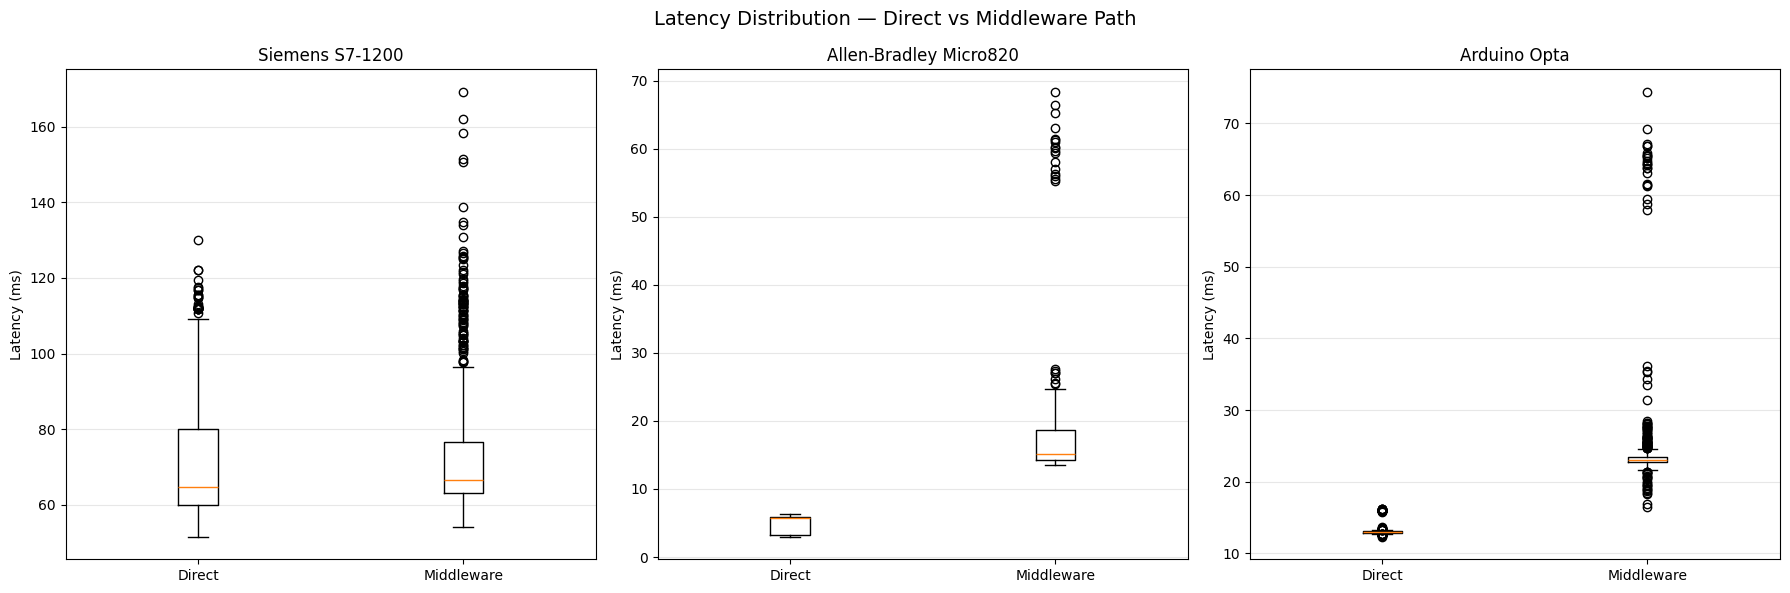

In [2]:
fig, axes = plt.subplots(1, len(devices), figsize=(6 * len(devices), 6), sharey=False)
if len(devices) == 1:
    axes = [axes]

for ax, device in zip(axes, devices):
    device_data = raw[raw["device"] == device]
    direct_vals = device_data[device_data["path"] == "Direct"]["latency_ms"]
    middleware_vals = device_data[device_data["path"] == "Middleware"]["latency_ms"]

    ax.boxplot([direct_vals, middleware_vals], labels=["Direct", "Middleware"], showfliers=True)
    ax.set_title(device)
    ax.set_ylabel("Latency (ms)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Latency Distribution — Direct vs Middleware Path", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Bar Chart — Mean Latency (Direct vs Middleware, all devices)

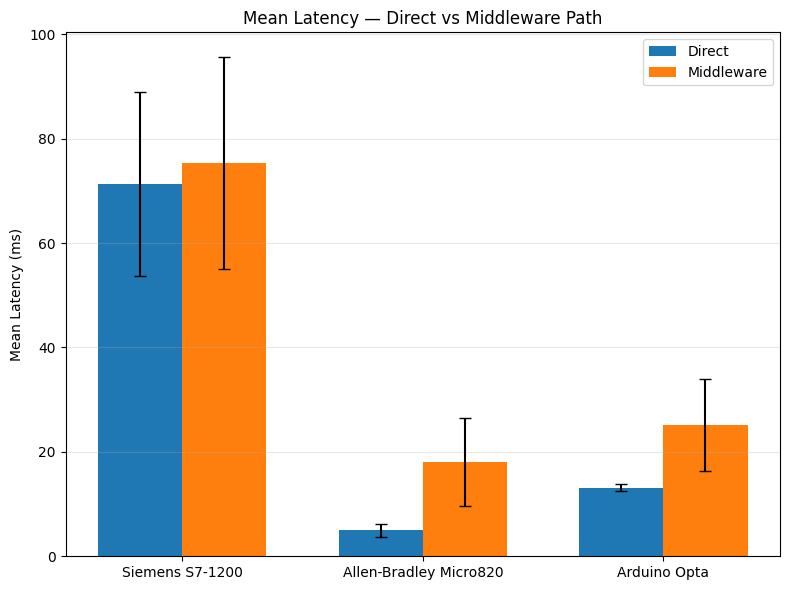

In [3]:
import numpy as np

x = np.arange(len(devices))
width = 0.35

direct_means = summary["direct_mean_ms"].values
middleware_means = summary["middleware_mean_ms"].values
direct_std = summary["direct_std_ms"].values
middleware_std = summary["middleware_std_ms"].values

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, direct_means, width, yerr=direct_std, capsize=4, label="Direct")
ax.bar(x + width/2, middleware_means, width, yerr=middleware_std, capsize=4, label="Middleware")

ax.set_xticks(x)
ax.set_xticklabels(devices)
ax.set_ylabel("Mean Latency (ms)")
ax.set_title("Mean Latency — Direct vs Middleware Path")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()